In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [4]:
column_names = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [5]:
df = pd.read_csv("dataset/wdbc.data", header=None, names=column_names)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [7]:
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [8]:
print(y.value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


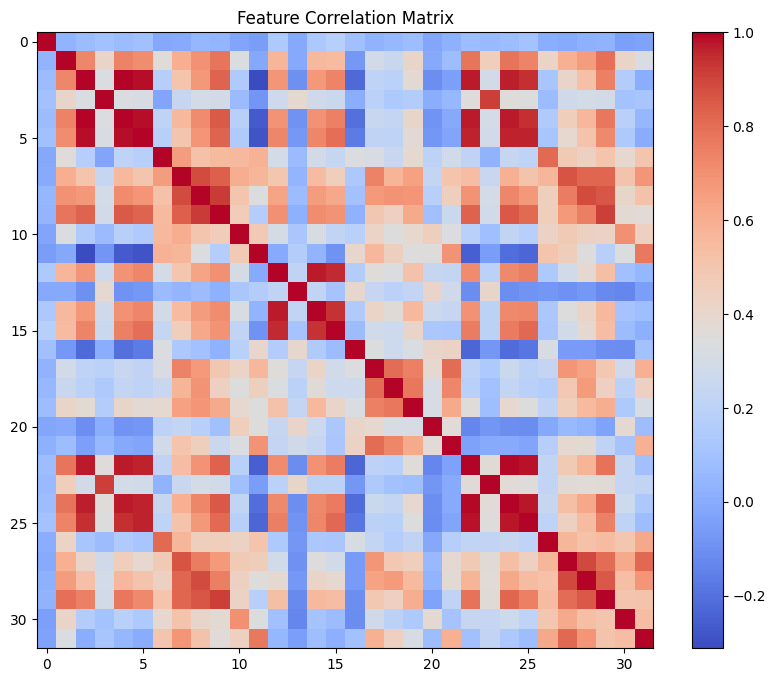

In [11]:
correlation_matrix = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, cmap='coolwarm')
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.savefig("images/correlation.png", dpi=300)

plt.show()

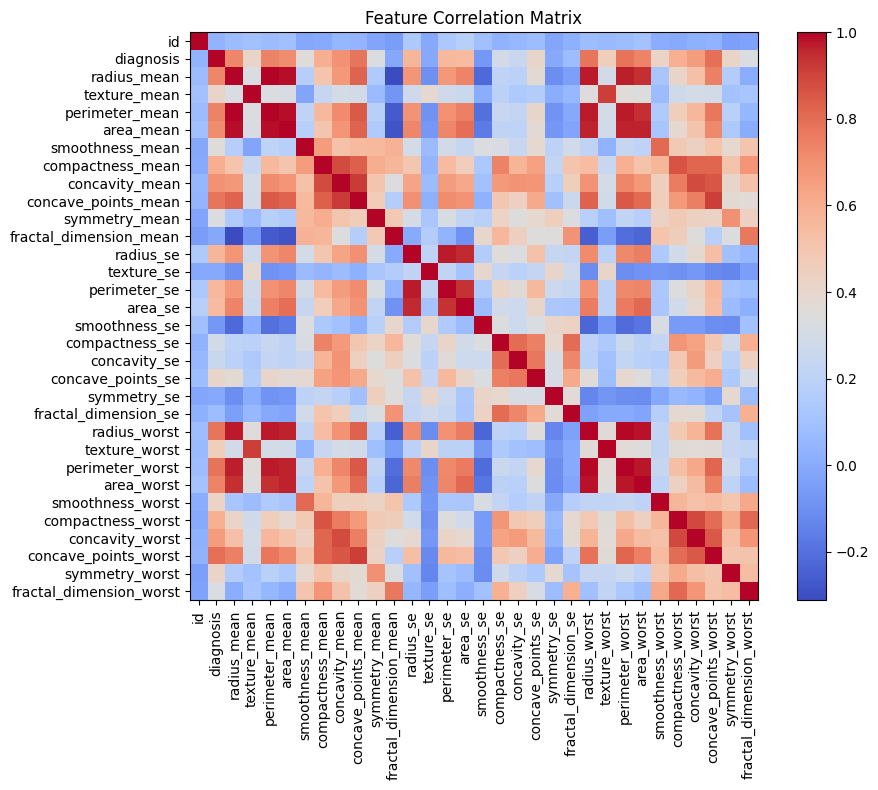

In [12]:
correlation_matrix = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, cmap='coolwarm')

# Add colorbar
plt.colorbar()

# Add axis labels (column names)
plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()

plt.savefig("images/correlation.png", dpi=300)
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9473684210526315


In [29]:
from sklearn.linear_model import LinearRegression

In [1]:
GridSearchCV?

Object `GridSearchCV` not found.


In [11]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy'
)

dt_grid.fit(X_train, y_train)

print("Best DT Parameters:", dt_grid.best_params_)
print("Best CV Accuracy:", dt_grid.best_score_)

Best DT Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Accuracy: 0.9428571428571428


In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544


In [13]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy'
)

rf_grid.fit(X_train, y_train)

print("Best RF Parameters:", rf_grid.best_params_)
print("Best RF CV Accuracy:", rf_grid.best_score_)

Best RF Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
Best RF CV Accuracy: 0.9648351648351647


In [14]:
print("Decision Tree Report\n", classification_report(y_test, y_pred_dt))
print("Random Forest Report\n", classification_report(y_test, y_pred_rf))

Decision Tree Report
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Random Forest Report
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [15]:
dt_cv = cross_val_score(dt, X, y, cv=5)
rf_cv = cross_val_score(rf, X, y, cv=5)

print("DT Fold Accuracies:", dt_cv)
print("DT Average:", dt_cv.mean())

print("RF Fold Accuracies:", rf_cv)
print("RF Average:", rf_cv.mean())

DT Fold Accuracies: [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
DT Average: 0.9173420276354604
RF Fold Accuracies: [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
RF Average: 0.9560937742586555


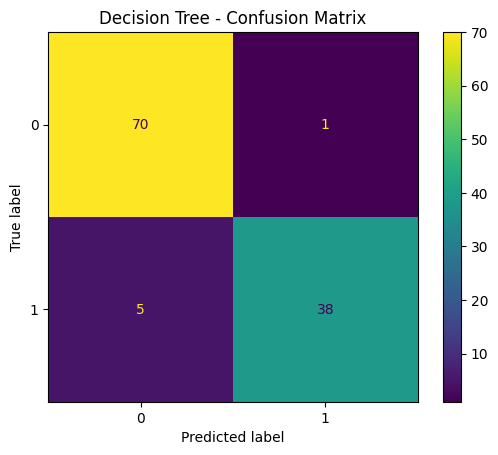

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    dt_grid.best_estimator_,   # or dt if not using GridSearch
    X_test,
    y_test
)

plt.title("Decision Tree - Confusion Matrix")
plt.savefig("images/conf_dt.png", dpi=300)

plt.show()

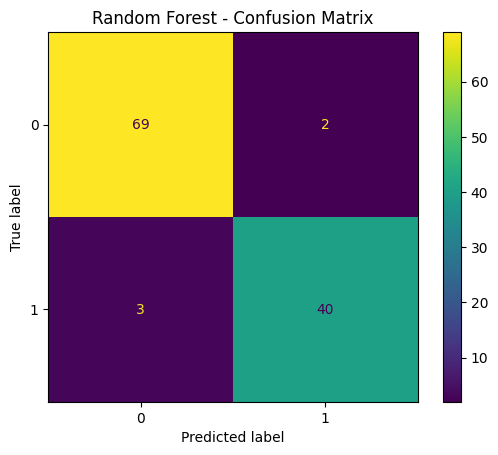

In [17]:
ConfusionMatrixDisplay.from_estimator(
    rf_grid.best_estimator_,   # or rf if not using GridSearch
    X_test,
    y_test
)

plt.title("Random Forest - Confusion Matrix")
plt.savefig("images/conf_rf.png", dpi=300)

plt.show()

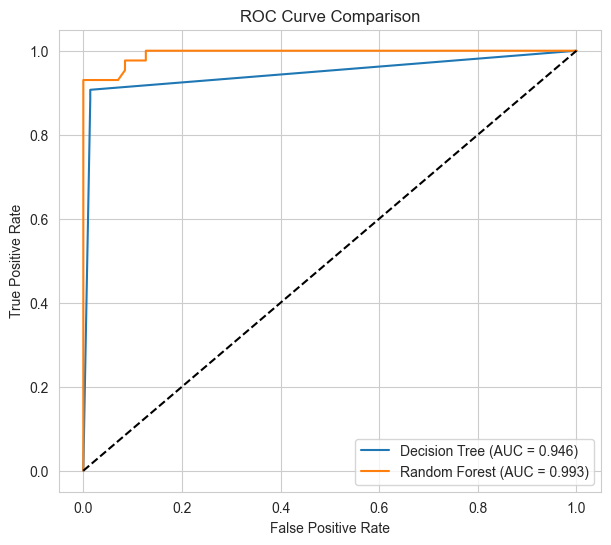

In [18]:
from sklearn.metrics import roc_curve, auc

# Probabilities
dt_probs = dt_grid.best_estimator_.predict_proba(X_test)[:,1]
rf_probs = rf_grid.best_estimator_.predict_proba(X_test)[:,1]

# ROC values
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(7,6))
sns.set_style("whitegrid")

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0,1], [0,1], 'k--')  # Diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("images/roc.png", dpi=300)

plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring=['accuracy', 'f1'],   # 👈 Multiple metrics
    refit='accuracy',             # Best model selected using accuracy
    return_train_score=False
)

dt_grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5]}"
,scoring,"['accuracy', 'f1']"
,n_jobs,None
,refit,'accuracy'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [20]:
results_dt = pd.DataFrame(dt_grid.cv_results_)

best_dt = results_dt.sort_values(by='mean_test_accuracy', ascending=False).head(1)

best_dt['mean_test_accuracy'] *= 100

print(best_dt[[
    'param_criterion',
    'param_max_depth',
    'mean_test_accuracy',
    'mean_test_f1'
]])

   param_criterion param_max_depth  mean_test_accuracy  mean_test_f1
20         entropy               3           94.285714      0.923164


In [21]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring=['accuracy', 'f1'],
    refit='accuracy',
    return_train_score=False
)

rf_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100]}"
,scoring,"['accuracy', 'f1']"
,n_jobs,None
,refit,'accuracy'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [22]:
results_rf = pd.DataFrame(rf_grid.cv_results_)

best_rf = results_rf.sort_values(by='mean_test_accuracy', ascending=False).head(1)

best_rf['mean_test_accuracy'] *= 100

print(best_rf[[
    'param_n_estimators',
    'param_max_depth',
    'param_max_features',
    'mean_test_accuracy',
    'mean_test_f1'
]])

   param_n_estimators param_max_depth param_max_features  mean_test_accuracy  \
3                 100            None               log2           96.043956   

   mean_test_f1  
3      0.946037  


Top 6 Important Features: ['concave_points_worst', 'concavity_mean', 'area_worst', 'concave_points_mean', 'radius_worst', 'perimeter_mean']


C:\Users\HP\AppData\Local\Temp\ipykernel_21760\585938779.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[feature], palette="Set2")
C:\Users\HP\AppData\Local\Temp\ipykernel_21760\585938779.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[feature], palette="Set2")
C:\Users\HP\AppData\Local\Temp\ipykernel_21760\585938779.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X[feature], palette="Set2")
C:\Users\HP\AppData\Local\Temp\ipykernel_21760\585938779.py:26: FutureWarning: 

Passing `palette` without assig

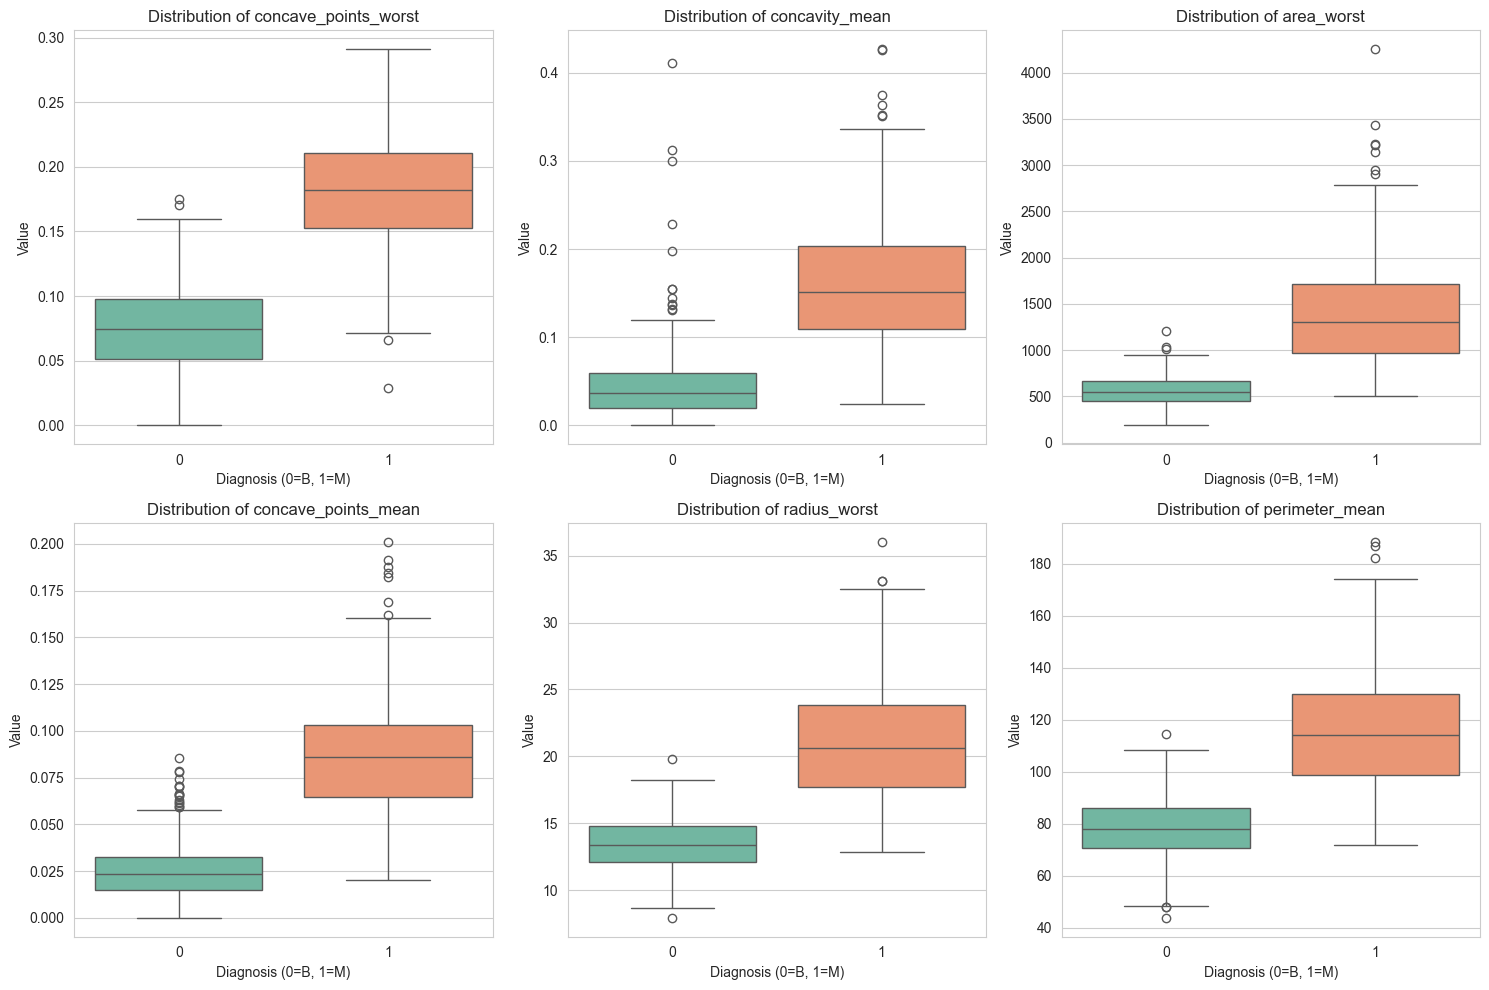

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Feature Importances from your trained Random Forest model
# (Assuming 'rf_grid.best_estimator_' is your optimized model)
importances = rf_grid.best_estimator_.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for ranking
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Select the Top 5 features
top_5_features = feature_importance_df.head(6)['Feature'].tolist()
print(f"Top 6 Important Features: {top_5_features}")

# 4. Create the Box Plots
plt.figure(figsize=(15, 10))

# We use a loop to create a subplot for each of the top 5 features
for i, feature in enumerate(top_5_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=y, y=X[feature], palette="Set2")
    plt.title(f'Distribution of {feature}')
    plt.xlabel('Diagnosis (0=B, 1=M)')
    plt.ylabel('Value')

plt.tight_layout()
plt.savefig("images/box_imp.png", dpi=450)

plt.show()